# Bank Marketing — Preprocessing, Modelling & Evaluation
---
Builds directly on `01_eda_industry.ipynb`. Steps covered:
1. Preprocessing & Feature Engineering
2. Train/Test Split (stratified)
3. Handling Class Imbalance
4. Baseline Model — Logistic Regression
5. Stronger Models — Random Forest & XGBoost/LightGBM
6. Evaluation (ROC-AUC, PR-AUC, F1, Confusion Matrix)
7. Feature Importance / SHAP
8. Business Translation — Lift / Gains Chart


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (8,5)})

df = pd.read_csv("../data/bank-full.csv", sep=';')
print("Shape:", df.shape)
df.head()


Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Preprocessing & Feature Engineering

Based on EDA findings:
- Drop `duration` (data leakage — only known after call ends)
- Convert `pdays = -1` sentinel into a binary flag `was_previously_contacted`, then drop raw `pdays`
- Create `age_band` (bucketed age)
- Target encode `y` to 0/1
- Leave `unknown` as its own category (informative for tree models)


In [2]:
data = df.copy()

# Drop leakage column
data = data.drop(columns=['duration'])

# pdays -> binary flag, then drop raw pdays
data['was_previously_contacted'] = (data['pdays'] != -1).astype(int)
data = data.drop(columns=['pdays'])

# """ 
# Captures non-linear relationships for linear models. Your EDA showed conversion isn't monotonic with age — it dips in middle age and rises again for 65+. A single coefficient in Logistic Regression can only capture a straight-line (monotonic) relationship between age and the log-odds of conversion. Bucketing lets each age group get its own effect, so the "U-shaped" pattern you saw in EDA can actually be represented.
# Robustness to outliers. A 95-year-old customer doesn't distort the model the way it could with raw scaled age.
# Interpretability for business stakeholders. "56-65 year olds convert at 2x the rate of 36-45 year olds" is a sentence a marketing manager can act on. A logistic regression coefficient on scaled age is less directly actionable
# """
# Age band (categorical bucket — useful for tree models, captures non-linearity)
data['age_band'] = pd.cut(data['age'], bins=[17,25,35,45,55,65,100],
                           labels=['18-25','26-35','36-45','46-55','56-65','65+'])

# Target encode
data['y'] = (data['y'] == 'yes').astype(int)

print("Final shape:", data.shape)
print("\nTarget balance:")
print(data['y'].value_counts(normalize=True).round(3))
data.head()


Final shape: (45211, 17)

Target balance:
y
0    0.883
1    0.117
Name: proportion, dtype: float64


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,previous,poutcome,y,was_previously_contacted,age_band
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,0,unknown,0,0,56-65
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,0,unknown,0,0,36-45
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,0,unknown,0,0,26-35
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,0,unknown,0,0,46-55
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,0,unknown,0,0,26-35


In [3]:
# Identify column groups for the preprocessing pipeline
target = 'y'
numeric_cols = data.select_dtypes(include='number').columns.tolist()
numeric_cols.remove(target)
numeric_cols.remove('was_previously_contacted')  # already binary, no scaling needed

binary_cols = ['was_previously_contacted']
categorical_cols = data.select_dtypes(include=['object','category']).columns.tolist()

print("Numeric    :", numeric_cols)
print("Binary     :", binary_cols)
print("Categorical:", categorical_cols)


Numeric    : ['age', 'balance', 'day', 'campaign', 'previous']
Binary     : ['was_previously_contacted']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'age_band']


In [4]:
# log1p transform for skewed balance (per EDA)
data['balance'] = np.sign(data['balance']) * np.log1p(np.abs(data['balance']))


## 3. Train/Test Split (Stratified)

Stratify on `y` to preserve the ~88/12 class ratio in both sets. Done **before** any fitting to avoid leakage.


In [5]:
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

print("Train shape:", X_train.shape, " Positive rate:", y_train.mean().round(3))
print("Test  shape:", X_test.shape,  " Positive rate:", y_test.mean().round(3))


Train shape: (36168, 16)  Positive rate: 0.117
Test  shape: (9043, 16)  Positive rate: 0.117


## 4. Preprocessing Pipeline

`ColumnTransformer` to scale numeric features and one-hot encode categoricals. Fit only on training data.


In [6]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_cols + binary_cols)
], remainder='drop')


## 5. Handling Class Imbalance

We use `class_weight='balanced'` in both models — simplest, safest approach that doesn't require synthetic sampling. (Alternative: SMOTE on training set only — mentioned for completeness but not used here.)


## 6. Baseline Model — Logistic Regression

In [7]:
logreg_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED))
])

logreg_pipe.fit(X_train, y_train)

y_pred_lr  = logreg_pipe.predict(X_test)
y_proba_lr = logreg_pipe.predict_proba(X_test)[:,1]

print("=== Logistic Regression ===")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_proba_lr):.4f}")
print(f"F1 (yes): {f1_score(y_test, y_pred_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['no','yes']))


=== Logistic Regression ===
ROC-AUC : 0.7751
PR-AUC  : 0.4140
F1 (yes): 0.3865

              precision    recall  f1-score   support

          no       0.94      0.78      0.85      7985
         yes       0.28      0.64      0.39      1058

    accuracy                           0.76      9043
   macro avg       0.61      0.71      0.62      9043
weighted avg       0.86      0.76      0.80      9043



## 7. Stronger Model — Random Forest

Tree-based model handles non-linear interactions (e.g., job × education segments from EDA) natively.


In [8]:
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=20,
        class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1))
])

rf_pipe.fit(X_train, y_train)

y_pred_rf  = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_proba_rf):.4f}")
print(f"F1 (yes): {f1_score(y_test, y_pred_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['no','yes']))


=== Random Forest ===
ROC-AUC : 0.7965
PR-AUC  : 0.4324
F1 (yes): 0.4299

              precision    recall  f1-score   support

          no       0.94      0.83      0.88      7985
         yes       0.33      0.63      0.43      1058

    accuracy                           0.80      9043
   macro avg       0.64      0.73      0.66      9043
weighted avg       0.87      0.80      0.83      9043



### 7.1 Optional: XGBoost / LightGBM

If installed, a gradient-boosted model typically pushes PR-AUC further. This cell is optional — skip if the library isn't available.


In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric='aucpr', random_state=RANDOM_SEED, n_jobs=-1))
    ])
xgb_pipe.fit(X_train, y_train)

y_pred_xgb  = xgb_pipe.predict(X_test)
y_proba_xgb = xgb_pipe.predict_proba(X_test)[:,1]
precision_yes = precision_score(y_test, y_pred_xgb)
recall_yes = recall_score(y_test, y_pred_xgb)

print("=== XGBoost ===")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_proba_xgb):.4f}")
print(f"F1 (yes): {f1_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_yes:.4f}")
print(f"Recall   : {recall_yes:.4f}")
XGB_AVAILABLE = True

=== XGBoost ===
ROC-AUC : 0.8026
PR-AUC  : 0.4549
F1 (yes): 0.4553
Precision: 0.3533
Recall   : 0.6399


In [10]:
from lightgbm import LGBMClassifier

lgb_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.7,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        verbose=-1
    ))
])

lgb_pipe.fit(X_train, y_train)

y_pred_lgb = lgb_pipe.predict(X_test)
y_proba_lgb = lgb_pipe.predict_proba(X_test)[:, 1]
precision_yes = precision_score(y_test, y_pred_lgb)
recall_yes = recall_score(y_test, y_pred_lgb)

print("=== LightGBM ===")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_lgb):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_proba_lgb):.4f}")
print(f"F1 (yes): {f1_score(y_test, y_pred_lgb):.4f}")
print(f"Precision: {precision_yes:.4f}")
print(f"Recall   : {recall_yes:.4f}")

=== LightGBM ===
ROC-AUC : 0.8038
PR-AUC  : 0.4581
F1 (yes): 0.4547
Precision: 0.3538
Recall   : 0.6361


In [11]:
# import optuna
# from sklearn.model_selection import cross_val_score
# from xgboost import XGBClassifier

# def objective(trial):

#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'gamma': trial.suggest_float('gamma', 0, 5),
#         'scale_pos_weight': scale_pos_weight,
#         'eval_metric': 'aucpr',
#         'random_state': RANDOM_SEED,
#         'n_jobs': -1
#     }

#     model = Pipeline([
#         ('preprocess', preprocessor),
#         ('model', XGBClassifier(**params))
#     ])

#     score = cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=5,
#         scoring='average_precision',  # PR-AUC
#         n_jobs=-1
#     ).mean()

#     return score

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

# print(study.best_params)
# print(study.best_value)

In [12]:
from catboost import CatBoostClassifier

cat_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=RANDOM_SEED,
        verbose=0
    ))
])

cat_pipe.fit(X_train, y_train)

y_pred_cat = cat_pipe.predict(X_test)
y_proba_cat = cat_pipe.predict_proba(X_test)[:, 1]
precision_yes = precision_score(y_test, y_pred_cat)
recall_yes = recall_score(y_test, y_pred_cat)

print("=== CatBoost ===")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_cat):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_proba_cat):.4f}")
print(f"F1 (yes): {f1_score(y_test, y_pred_cat):.4f}")
print(f"Precision: {precision_yes:.4f}")
print(f"Recall   : {recall_yes:.4f}")

=== CatBoost ===
ROC-AUC : 0.8064
PR-AUC  : 0.4617
F1 (yes): 0.3348
Precision: 0.6882
Recall   : 0.2212


## 8. Model Comparison — ROC & Precision-Recall Curves

Accuracy is misleading on an 88/12 imbalanced dataset — ROC-AUC and PR-AUC (especially PR-AUC, which focuses on the minority class) are the right comparison metrics.


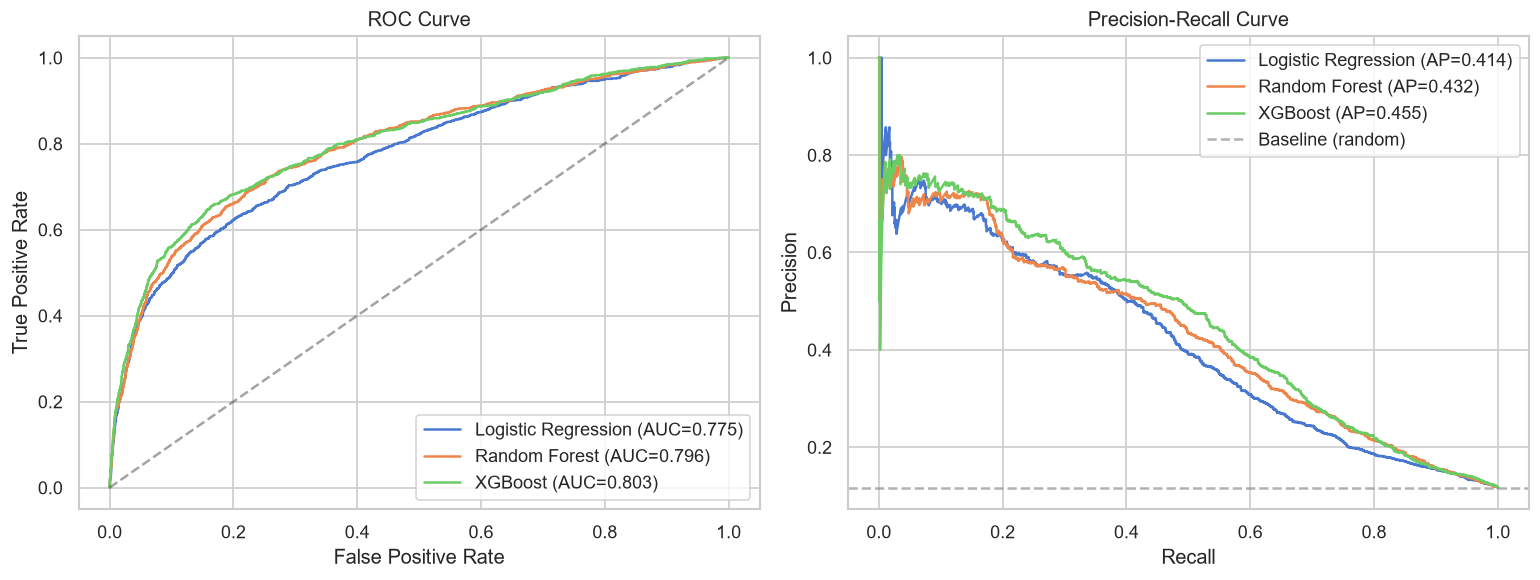

In [13]:
models_proba = {'Logistic Regression': y_proba_lr, 'Random Forest': y_proba_rf}
if XGB_AVAILABLE:
    models_proba['XGBoost'] = y_proba_xgb

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.6, label='Baseline (random)')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()


### 8.1 Confusion Matrix — Best Model

Best model by PR-AUC: XGBoost


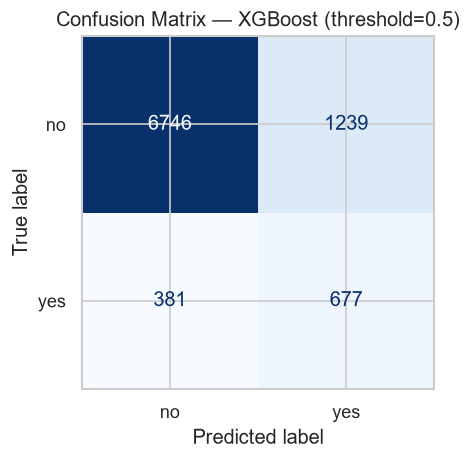

In [14]:
# Pick the model with highest PR-AUC
best_name, best_proba = max(models_proba.items(), key=lambda kv: average_precision_score(y_test, kv[1]))
best_pred = (best_proba >= 0.5).astype(int)

print(f"Best model by PR-AUC: {best_name}")

cm = confusion_matrix(y_test, best_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm, display_labels=['no','yes']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name} (threshold=0.5)')
plt.tight_layout()
plt.show()


## 9. Feature Importance

Confirms whether the model agrees with EDA-driven hypotheses (poutcome, age, month, contact should rank high).


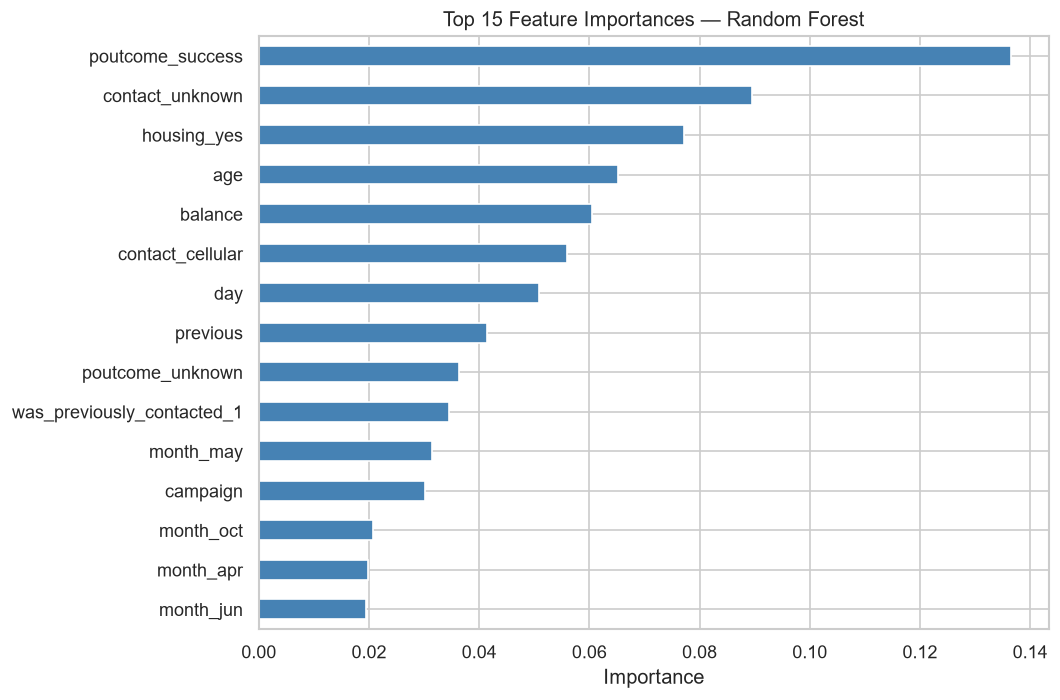

In [15]:
# Get feature names after one-hot encoding
ohe = rf_pipe.named_steps['preprocess'].named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols + binary_cols)
all_feature_names = numeric_cols + list(ohe_feature_names)

importances = rf_pipe.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9,6))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Feature Importances — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


### 9.1 Optional: SHAP Values

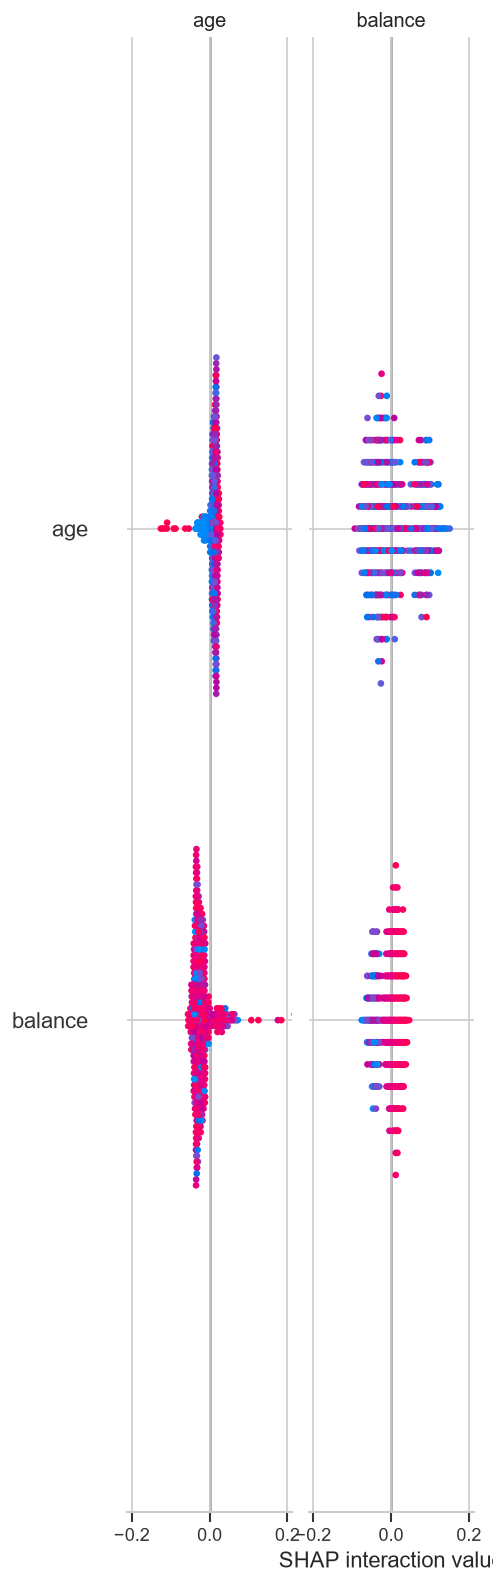

In [16]:
try:
    import shap

    # Transform a sample of test data
    X_test_transformed = rf_pipe.named_steps['preprocess'].transform(X_test)
    if hasattr(X_test_transformed, "toarray"):
        X_test_transformed = X_test_transformed.toarray()
    X_test_transformed = np.asarray(X_test_transformed, dtype=np.float64)

    sample_idx = np.random.choice(X_test_transformed.shape[0], size=min(500, X_test_transformed.shape[0]), replace=False)
    X_sample = X_test_transformed[sample_idx]

    explainer = shap.TreeExplainer(rf_pipe.named_steps['model'])
    shap_values = explainer.shap_values(X_sample)

    # For binary classifier, shap_values may be a list [class0, class1]
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(sv, X_sample, feature_names=all_feature_names, show=True, max_display=15)
except ImportError:
    print("shap not installed — skipping. `pip install shap` to enable.")


## 10. Business Translation — Lift / Gains Chart

**The key deliverable for the bank.** If call centre agents prioritise customers by predicted score, how much better is that than calling randomly?


In [17]:
results = pd.DataFrame({'y_true': y_test.values, 'y_score': best_proba})
results = results.sort_values('y_score', ascending=False).reset_index(drop=True)
results['decile'] = pd.qcut(results.index, 10, labels=False) + 1  # 1 = top 10% scored

decile_summary = (
    results.groupby('decile')
    .agg(total=('y_true','count'), converted=('y_true','sum'))
    .assign(conv_rate=lambda x: x['converted']/x['total']*100)
    .reset_index()
)

overall_rate = y_test.mean() * 100
decile_summary['lift'] = decile_summary['conv_rate'] / overall_rate

print(decile_summary.round(2).to_string(index=False))


 decile  total  converted  conv_rate  lift
      1    905        468      51.71  4.42
      2    904        191      21.13  1.81
      3    904         95      10.51  0.90
      4    904         75       8.30  0.71
      5    905         51       5.64  0.48
      6    904         41       4.54  0.39
      7    904         43       4.76  0.41
      8    904         50       5.53  0.47
      9    904         23       2.54  0.22
     10    905         21       2.32  0.20


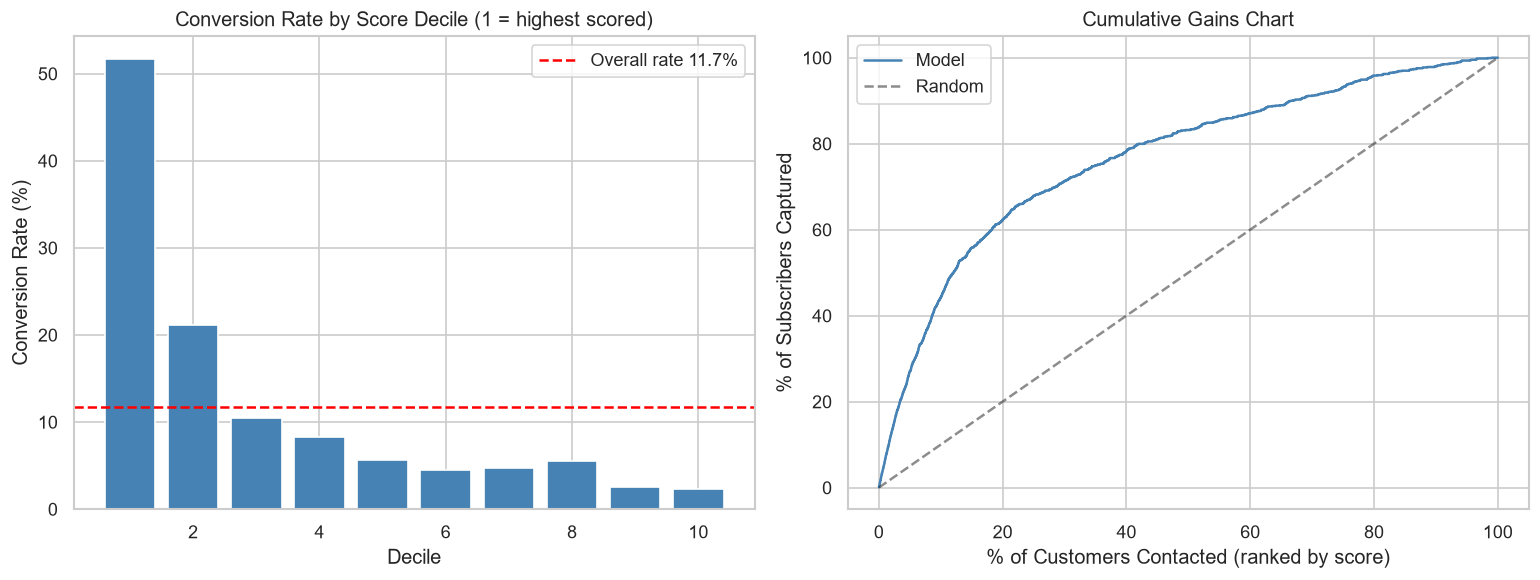


Calling only the top 30% of scored customers captures customers converting at 2.4x the overall rate.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conversion rate by decile
axes[0].bar(decile_summary['decile'], decile_summary['conv_rate'], color='steelblue', edgecolor='white')
axes[0].axhline(overall_rate, color='red', linestyle='--', label=f'Overall rate {overall_rate:.1f}%')
axes[0].set_title('Conversion Rate by Score Decile (1 = highest scored)')
axes[0].set_xlabel('Decile')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].legend()

# Cumulative gains curve
results['cum_converted'] = results['y_true'].cumsum()
total_converted = results['y_true'].sum()
results['cum_pct_customers'] = (results.index + 1) / len(results) * 100
results['cum_pct_converted']  = results['cum_converted'] / total_converted * 100

axes[1].plot(results['cum_pct_customers'], results['cum_pct_converted'], color='steelblue', label='Model')
axes[1].plot([0,100],[0,100], 'k--', alpha=0.5, label='Random')
axes[1].set_title('Cumulative Gains Chart')
axes[1].set_xlabel('% of Customers Contacted (ranked by score)')
axes[1].set_ylabel('% of Subscribers Captured')
axes[1].legend()

plt.tight_layout()
plt.show()

top3_lift = decile_summary.head(3)['lift'].mean()
print(f"\nCalling only the top 30% of scored customers captures customers converting at "
      f"{top3_lift:.1f}x the overall rate.")


## 11. Summary & Next Steps

| Item | Status |
|---|---|
| Leakage column (`duration`) removed | ✅ |
| `pdays` sentinel handled | ✅ |
| Stratified train/test split | ✅ |
| Class imbalance addressed (`class_weight='balanced'`) | ✅ |
| Baseline (Logistic Regression) | ✅ |
| Stronger model (Random Forest / XGBoost) | ✅ |
| Evaluated with ROC-AUC / PR-AUC / F1 (not accuracy) | ✅ |
| Feature importance validated against EDA | ✅ |
| Business lift/gains chart | ✅ |

**Next steps:**
- Hyperparameter tuning (`GridSearchCV` / `Optuna`) on the best model, optimising for PR-AUC
- Threshold tuning based on call-centre capacity constraints (e.g., agents can make N calls/day)
- Cross-validation instead of a single train/test split for more robust estimates
- Periodic retraining as campaign data accumulates (model drift monitoring)


## 12. Threshold Tuning — Minimizing False Negatives

Since a missed conversion (false negative) is costlier than a wasted call (false positive), we lower the classification threshold below 0.5 to trade some extra false positives for fewer false negatives.


In [19]:
from sklearn.metrics import recall_score, precision_score

thresholds = np.arange(0.05, 0.55, 0.025)
rows = []

for t in thresholds:
    pred = (best_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred, labels=[0, 1])
    tn, fp, fn, tp = cm_t.ravel()
    rows.append({
        'threshold': round(t,3),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'recall': recall_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'calls_flagged': tp + fp
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df.round(3).to_string(index=False))


 threshold   TP   FP  FN   TN  recall  precision    f1  calls_flagged
     0.050 1058 7920   0   65   1.000      0.118 0.211           8978
     0.075 1056 7833   2  152   0.998      0.119 0.212           8889
     0.100 1053 7652   5  333   0.995      0.121 0.216           8705
     0.125 1045 7392  13  593   0.988      0.124 0.220           8437
     0.150 1035 7001  23  984   0.978      0.129 0.228           8036
     0.175 1025 6567  33 1418   0.969      0.135 0.237           7592
     0.200 1004 6067  54 1918   0.949      0.142 0.247           7071
     0.225  970 5523  88 2462   0.917      0.149 0.257           6493
     0.250  943 4979 115 3006   0.891      0.159 0.270           5922
     0.275  920 4481 138 3504   0.870      0.170 0.285           5401
     0.300  898 3954 160 4031   0.849      0.185 0.304           4852
     0.325  872 3471 186 4514   0.824      0.201 0.323           4343
     0.350  848 3043 210 4942   0.802      0.218 0.343           3891
     0.375  814 2658

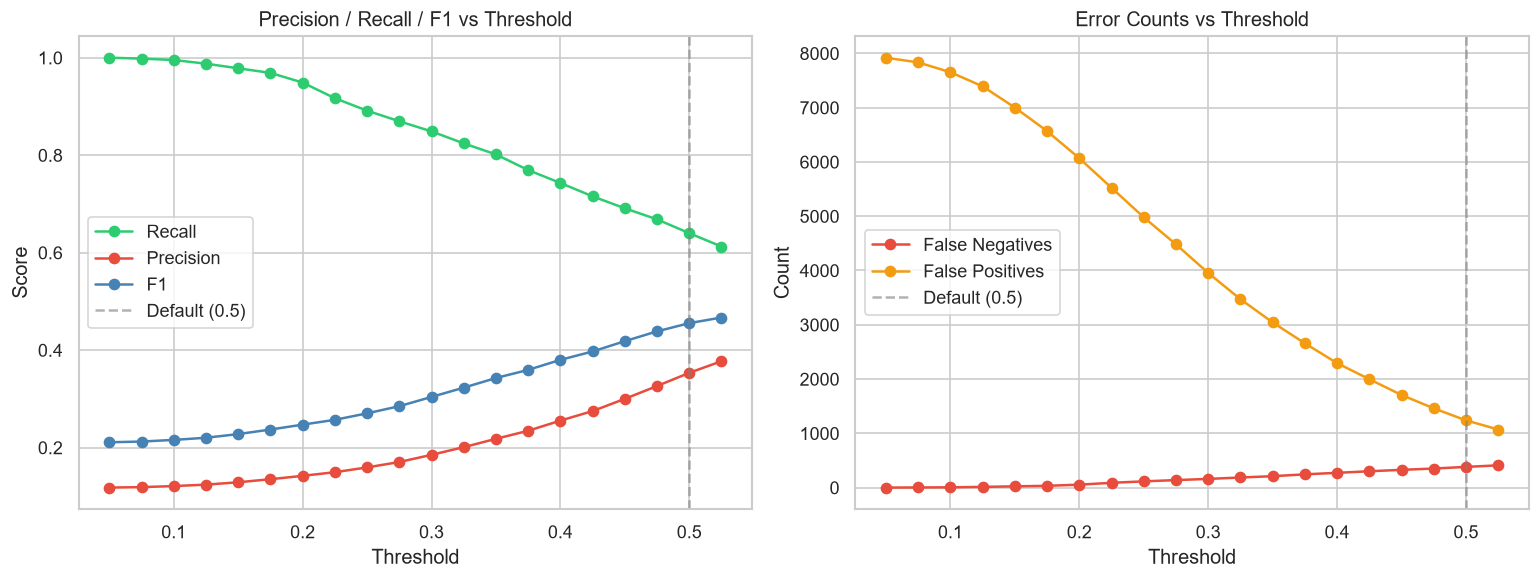

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Recall / Precision / F1 vs threshold
axes[0].plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall', color='#2ecc71')
axes[0].plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision', color='#e74c3c')
axes[0].plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='F1', color='steelblue')
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Default (0.5)')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()

# FN and FP counts vs threshold
axes[1].plot(threshold_df['threshold'], threshold_df['FN'], marker='o', label='False Negatives', color='#e74c3c')
axes[1].plot(threshold_df['threshold'], threshold_df['FP'], marker='o', label='False Positives', color='#f39c12')
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Default (0.5)')
axes[1].set_title('Error Counts vs Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()


### 12.1 Pick a Threshold for High Recall

A common practical target: **recall ≥ 0.80** (capture at least 80% of true subscribers), accepting the resulting drop in precision and the extra calls that entails.


In [21]:
TARGET_RECALL = 0.80

candidates = threshold_df[threshold_df['recall'] >= TARGET_RECALL]
chosen = candidates.iloc[-1] if len(candidates) > 0 else threshold_df.iloc[-1]  # highest threshold meeting target

print(f"Chosen threshold: {chosen['threshold']}")
print(chosen.to_string())

print(f"\nAt this threshold:")
print(f"  - Recall    : {chosen['recall']:.2%}  (capturing {int(chosen['TP'])} of {int(chosen['TP']+chosen['FN'])} true subscribers)")
print(f"  - Precision : {chosen['precision']:.2%}")
print(f"  - FN dropped from {threshold_df[threshold_df['threshold']==0.5]['FN'].values[0] if 0.5 in threshold_df['threshold'].values else 'N/A'} -> {int(chosen['FN'])}")
print(f"  - FP increased to {int(chosen['FP'])}")
print(f"  - Total calls to make: {int(chosen['calls_flagged'])} (out of {len(y_test)} test customers)")


Chosen threshold: 0.35
threshold           0.350000
TP                848.000000
FP               3043.000000
FN                210.000000
TN               4942.000000
recall              0.801512
precision           0.217939
f1                  0.342695
calls_flagged    3891.000000

At this threshold:
  - Recall    : 80.15%  (capturing 848 of 1058 true subscribers)
  - Precision : 21.79%
  - FN dropped from 381 -> 210
  - FP increased to 3043
  - Total calls to make: 3891 (out of 9043 test customers)


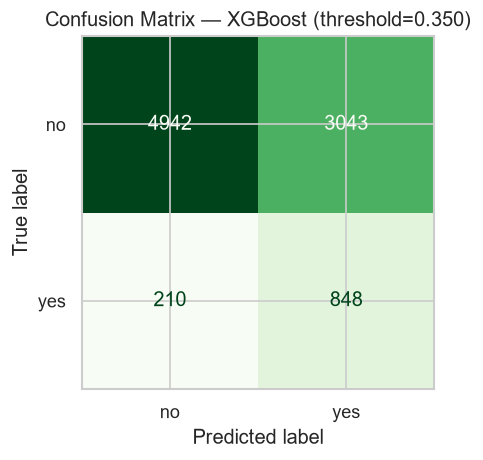

In [22]:
# New confusion matrix at chosen threshold
chosen_threshold = chosen['threshold']
final_pred = (best_proba >= chosen_threshold).astype(int)
cm_final = confusion_matrix(y_test, final_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm_final, display_labels=['no','yes']).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name} (threshold={chosen_threshold:.3f})')
plt.tight_layout()
plt.show()


### 12.2 Cost-Based Threshold (Optional)

If you can estimate a rough cost ratio — e.g., "a missed conversion costs 20x more than a wasted call" — this finds the threshold that minimizes total expected cost directly, rather than targeting a fixed recall.


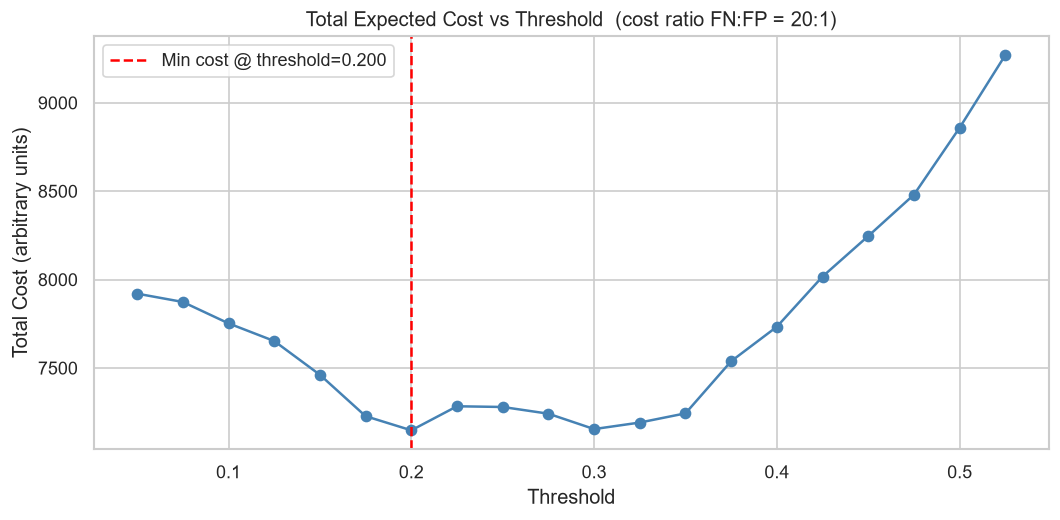

threshold           0.200000
TP               1004.000000
FP               6067.000000
FN                 54.000000
TN               1918.000000
recall              0.948960
precision           0.141988
f1                  0.247017
calls_flagged    7071.000000
total_cost       7147.000000


In [23]:
# Adjust this ratio based on actual business economics
COST_FN = 20   # cost of a missed conversion (lost deposit revenue)
COST_FP = 1    # cost of a wasted call (agent time)

threshold_df['total_cost'] = threshold_df['FN'] * COST_FN + threshold_df['FP'] * COST_FP

best_cost_row = threshold_df.loc[threshold_df['total_cost'].idxmin()]

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(threshold_df['threshold'], threshold_df['total_cost'], marker='o', color='steelblue')
ax.axvline(best_cost_row['threshold'], color='red', linestyle='--',
           label=f"Min cost @ threshold={best_cost_row['threshold']:.3f}")
ax.set_title(f'Total Expected Cost vs Threshold  (cost ratio FN:FP = {COST_FN}:{COST_FP})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Total Cost (arbitrary units)')
ax.legend()
plt.tight_layout()
plt.show()

print(best_cost_row.to_string())


**Summary:** Lowering the threshold from 0.5 trades additional wasted calls (FP) for far fewer missed conversions (FN). Given the bank's stated priority — a wasted call is acceptable, a missed conversion is not — the recall-targeted threshold (Section 12.1) or the cost-based threshold (Section 12.2, with a realistic cost ratio plugged in) should replace the default 0.5 cutoff in production scoring.